# Posterior for S. aureus local recombination rate using SBI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
import torch.nn as nn
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.neural_nets import posterior_nn
from sbi.neural_nets.embedding_nets import FCEmbedding
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load staph gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/staph/saureus_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                                                   , C1139
                                                                  ,|
                                                                  |, C9658
                                                                  ||
                                                                  |, C1282
                                                                  ||
                      ____________________________________________|, C1280
                     |                                            ||
                     |                                            || C1080
                     |                                            |
                     |                                            |_ C1079
                     |                                            |
                     |                                            , C1147
                     |                                          

In [3]:
x_obs_df = pd.read_csv("../data/staph/core_gene_summary_stats.csv", index_col=0)
x_obs_np = x_obs_df.to_numpy()
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([1983, 46]), torch.float32)

### Delete observations with no signal

In [4]:
no_signal_id = np.where(x_obs_np[:, 33] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((18,), array([ 137,  140,  236,  657,  659,  767,  773, 1036, 1485, 1497]))

In [5]:
x_obs_np = np.delete(x_obs_np, no_signal_id, axis=0)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

((1965, 46), torch.Size([1965, 46]), torch.float32)

## Load simulation data

In [6]:
theta1 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/staph/ClonalOrigin_sim/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/staph/ClonalOrigin_sim/x2.csv', delimiter=",")

theta3 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/staph/ClonalOrigin_sim/x3.csv', delimiter=",")

x = np.vstack([x1, x2, x3])
theta = np.vstack([theta1, theta2, theta3])

print(theta.shape, x.shape)

(50000, 2) (50000, 46)


In [7]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [8]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(46):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 33 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

Observation 5 is outside the range of simulated data.
Observation 6 is outside the range of simulated data.
Observation 7 is outside the range of simulated data.
Observation 8 is outside the range of simulated data.
Observation 14 is outside the range of simulated data.
Observation 16 is outside the range of simulated data.
Observation 20 is outside the range of simulated data.
Observation 22 is outside the range of simulated data.
Observation 27 is outside the range of simulated data.
Observation 29 is outside the range of simulated data.
Observation 30 is outside the range of simulated data.
Observation 31 is outside the range of simulated data.
Observation 35 is outside the range of simulated data.
Observation 39 is outside the range of simulated data.
Observation 47 is outside the range of simulated data.
Observation 50 is outside the range of simulated data.
Observation 60 is outside the range of simulated data.
Observation 64 is outside the range of simulated data.
Observation 82

In [9]:
len(ignore_indices), len(no_segregation), len(out_stats)

(297, 0, 297)

In [10]:
out_index_all = []
for i in range(len(ignore_indices)):
    idx = ignore_indices[i]
    out_index_all += out_stats[idx]

In [11]:
from collections import Counter

integer_counts = Counter(out_index_all)

In [12]:
for i in range(32):
    print(f"Index {i}: {integer_counts[i]}")

Index 0: 7
Index 1: 5
Index 2: 1
Index 3: 1
Index 4: 8
Index 5: 7
Index 6: 0
Index 7: 0
Index 8: 0
Index 9: 5
Index 10: 0
Index 11: 0
Index 12: 0
Index 13: 19
Index 14: 0
Index 15: 0
Index 16: 149
Index 17: 134
Index 18: 2
Index 19: 4
Index 20: 263
Index 21: 177
Index 22: 2
Index 23: 1
Index 24: 0
Index 25: 0
Index 26: 0
Index 27: 0
Index 28: 0
Index 29: 0
Index 30: 0
Index 31: 0


In [13]:
for i in range(32, 46):
    print(f"Index {i}: {integer_counts[i]}")

Index 32: 0
Index 33: 1
Index 34: 1
Index 35: 4
Index 36: 24
Index 37: 0
Index 38: 0
Index 39: 0
Index 40: 0
Index 41: 0
Index 42: 1
Index 43: 0
Index 44: 1
Index 45: 0


Drop columns for exact LD and G4 values

In [14]:
drop_columns = list(range(0, 8)) + list(range(16, 32))

In [15]:
len(drop_columns), drop_columns

(24,
 [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31])

In [16]:
x_obs_np = np.delete(x_obs_np, drop_columns, axis=1)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

((1965, 22), torch.Size([1965, 22]), torch.float32)

In [17]:
x = x[:, [i for i in range(x.shape[1]) if i not in drop_columns]]
x_numpy = x.cpu().numpy()
x.shape, x_numpy.shape

(torch.Size([50000, 22]), (50000, 22))

## NPE

### Create prior to pass range knowledge to NPE

In [18]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([20.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_L],
    validate_args=False,
    device=torch_device
)

### Embedding summary network

In [19]:
embedding_net = FCEmbedding(
        input_dim=22, 
        output_dim=4, 
        num_hiddens=32, 
        num_layers=2
    )

neural_posterior = posterior_nn(
    model="nsf", 
    embedding_net=embedding_net 
)

In [20]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference_summaryNN = NPE_C(prior=prior, density_estimator=neural_posterior, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [21]:
density_estimator_summaryNN = inference_summaryNN.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior_summaryNN = inference_summaryNN.build_posterior(density_estimator_summaryNN)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 4, 5, 8, 9, 12, 14, 15, 17, 18, 19, 20] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 88 epochs.

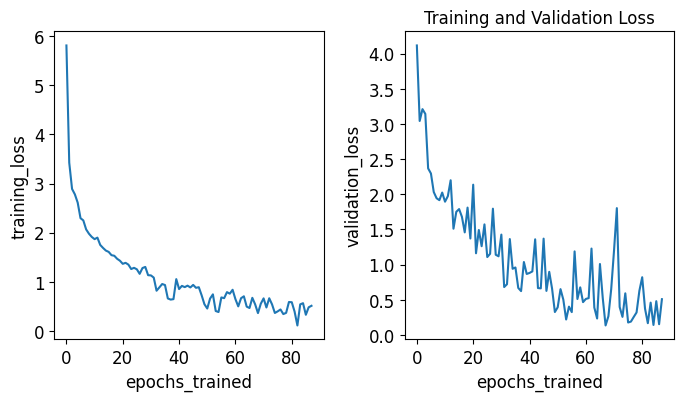

In [22]:
fig, axes = plot_summary(
    inference_summaryNN, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Plug in observation data to get posterior

In [23]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 2), np.nan)
theta_post.shape

(1965, 1000, 2)

In [25]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior_summaryNN.sample((num_posterior_samples,),
                                                  x=x_obs_torch[i, :],
                                                  show_progress_bars=False,
                                                  reject_outside_prior=False)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_16932\2061498089.py:5: UserWarning: 65.8% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post_torch = posterior_summaryNN.sample((num_posterior_samples,),
C:\Users\u2008181\AppData\Local\Temp\ipykernel_16932\2061498089.py:5: UserWarning: 8.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post_torch = posterior_summaryNN.sample((num_posterior_samples,),
C:\Users\u2008181\AppData\Local\Temp\ipykernel_16932\2061498089.py:5: UserWarning: 16.1% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post_torch = posterior_summaryNN.sample((num_posterior_samples,),
C:\Users\u2008181\AppData\Local\Temp\ipykernel_16932\2061498089.py:5: UserWarning: 11.6% of samples drawn with reject_outside_prior=False lie outside the prio

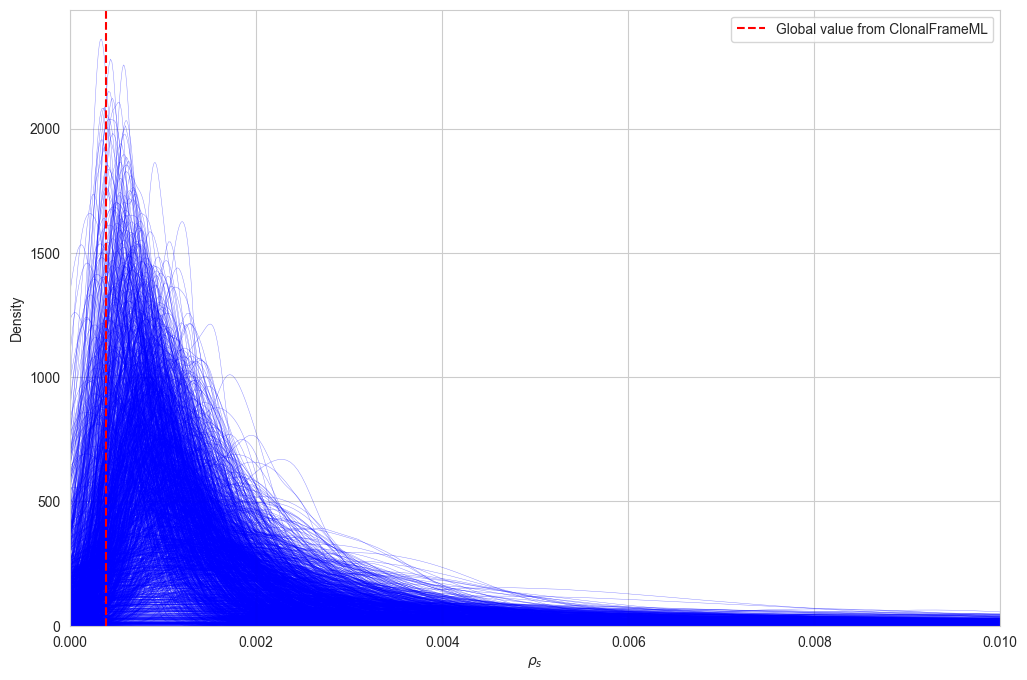

In [26]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    if i in ignore_indices:
        continue
    sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.axvline(x=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.01)
plt.legend()
plt.show()

### Plot bar plots by position

In [27]:
gene_info = pd.read_csv("../data/staph/core_gene_info.csv", index_col=0)
gene_info_np = gene_info.to_numpy()
gene_info.head()

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
dnaA,1362,517,1878,True
dnaN,1134,2156,3289,True
SAR0003,246,3670,3915,True
recF,1113,3912,5024,True
gyrB,1932,5037,6968,True


In [28]:
plot_xlim = [0.0, 2902619.0]
samples_x = np.delete(gene_info_np[:, 1], no_signal_id)
samples_x.shape

(1965,)

In [29]:
posterior_median = np.median(theta_post[:, :, 0], axis=1)
posterior_median.shape

(1965,)

In [30]:
ci_lower_bounds = np.percentile(theta_post[:, :, 0], 2.5, axis=1)
ci_upper_bounds = np.percentile(theta_post[:, :, 0], 97.5, axis=1)
ci_lower_bounds.shape, ci_upper_bounds.shape

((1965,), (1965,))

In [31]:
lower_errors = posterior_median - ci_lower_bounds
upper_errors = ci_upper_bounds - posterior_median
yerr = [lower_errors, upper_errors]

In [32]:
median_rho = np.median(posterior_median)
median_rho

np.float64(0.0010420400649309158)

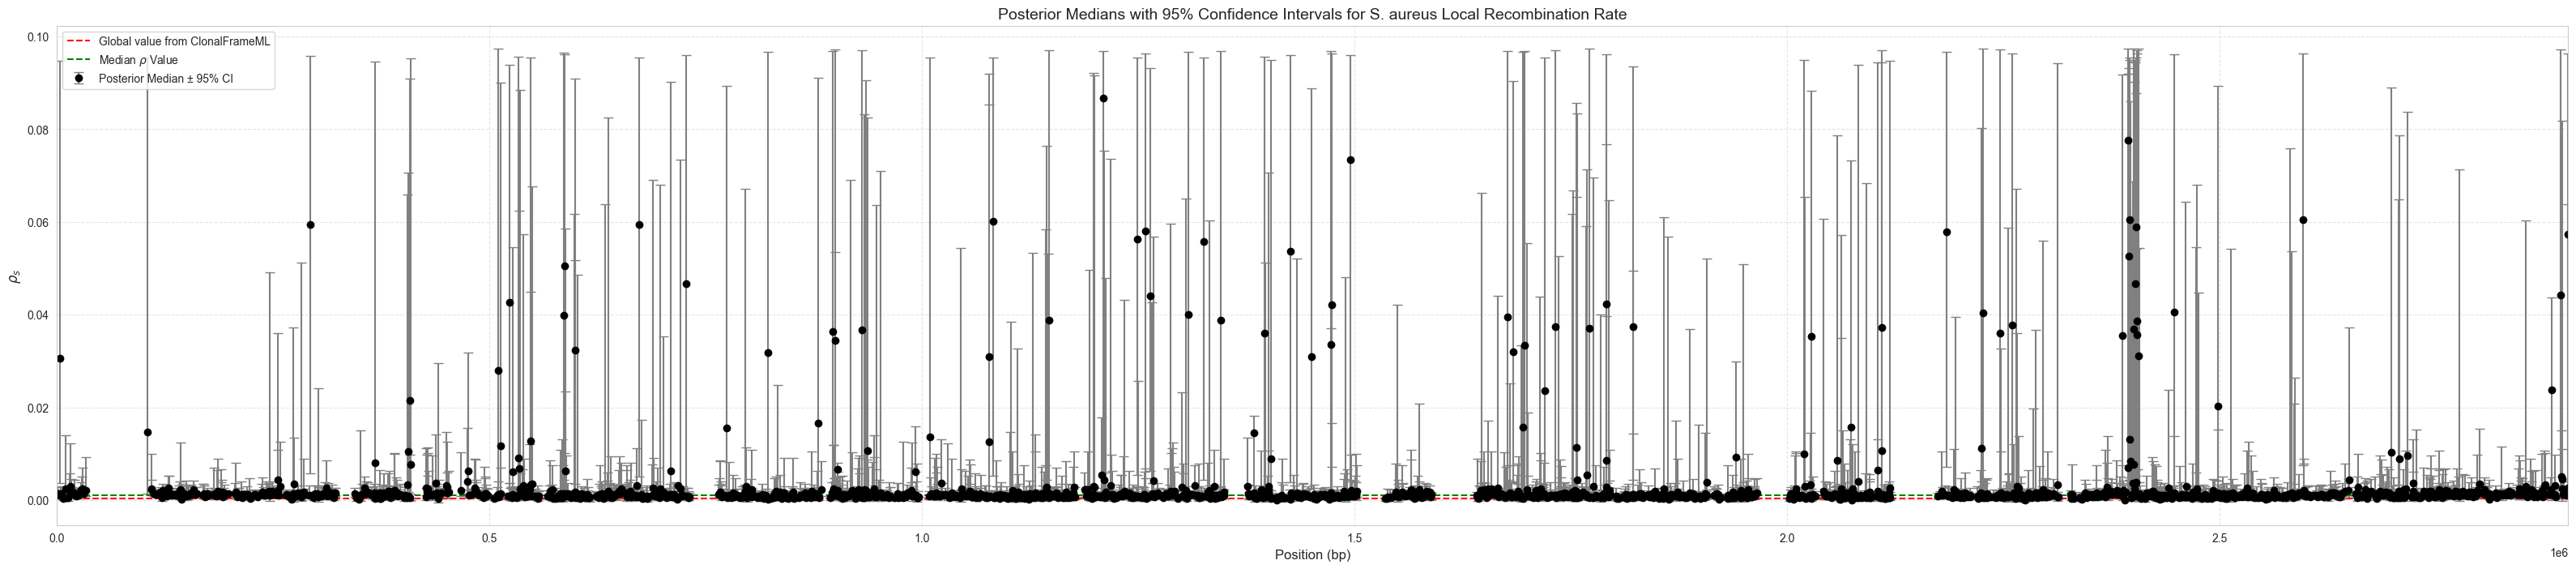

In [33]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median, yerr=yerr, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for S. aureus Local Recombination Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_rho, color='green', linestyle='dashed', label=r'Median $\rho$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [34]:
samples_l = np.delete(gene_info_np[:, 0], no_signal_id)
samples_l.shape

(1965,)

In [35]:
posterior_l_median = np.median(theta_post[:, :, 1], axis=1)
posterior_l_median.shape

(1965,)

In [36]:
ci_lower_bounds_l = np.percentile(theta_post[:, :, 1], 2.5, axis=1)
ci_upper_bounds_l = np.percentile(theta_post[:, :, 1], 97.5, axis=1)
ci_lower_bounds_l.shape, ci_upper_bounds_l.shape

((1965,), (1965,))

In [37]:
lower_l_errors = posterior_l_median - ci_lower_bounds_l
upper_l_errors = ci_upper_bounds_l - posterior_l_median
yerr_l = [lower_l_errors, upper_l_errors]

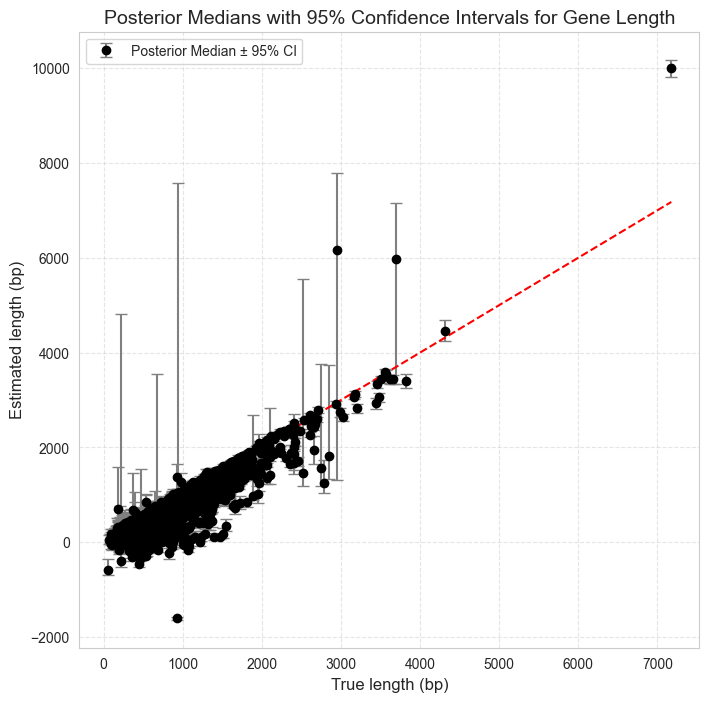

In [38]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l, posterior_l_median, yerr=yerr_l, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l), np.max(samples_l), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for Gene Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

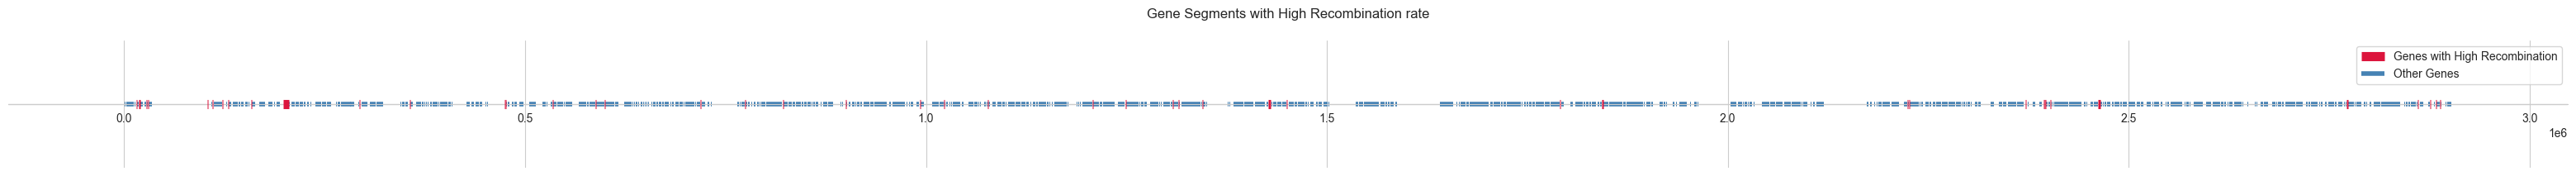

In [39]:
y_level = 0
gene_starts = np.delete(gene_info_np[:, 1], no_signal_id)
gene_ends   = np.delete(gene_info_np[:, 2], no_signal_id)

# high_recomb_index = np.where(ci_lower_bounds >= 0.0003887292720131564)[0]
high_recomb_index = np.where(ci_lower_bounds >= median_rho)[0]
highlight_starts = gene_starts[high_recomb_index]
highlight_ends   = gene_ends[high_recomb_index]

# other_genes_index = np.where(ci_lower_bounds < 0.0003887292720131564)[0]
other_genes_index = np.where(ci_lower_bounds < median_rho)[0]
other_starts = gene_starts[other_genes_index]
other_ends   = gene_ends[other_genes_index]

fig, ax = plt.subplots(figsize=(40, 2))

ax.axhline(y=y_level, color='lightgray', linewidth=1, zorder=1)
ax.hlines(y=[y_level] * len(highlight_starts), xmin=highlight_starts, xmax=highlight_ends, 
          color='crimson', linewidth=8, label='Genes with High Recombination', zorder=3)
ax.hlines(y=[y_level] * len(other_starts), xmin=other_starts, xmax=other_ends, 
          color='steelblue', linewidth=4, label='Other Genes', zorder=2)

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position('center')

ax.set_ylim(-1, 1)
ax.set_title("Gene Segments with High Recombination rate", pad=20)
ax.legend(loc='upper right')
plt.show()

### Embedding summary network where keep the gene length dimension

In [40]:
class LeaveLengthOut_NN(nn.Module):
    def __init__(self, input_dim=22, num_hiddens=32):
        super().__init__()
        
        # This MLP generates the first 3 features. 
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, num_hiddens),
            nn.ReLU(),
            nn.Linear(num_hiddens, num_hiddens),
            nn.ReLU(),
            nn.Linear(num_hiddens, 3)  # Output exactly 3 neurons
        )

    def forward(self, x):
        # 1. Get the 3 neurons from the MLP
        mlp_out = self.mlp(x)
        # 2. Extract the last element of the input vector
        last_element = x[:, -1:] 
        # 3. Concatenate them along the feature dimension
        out = torch.cat([mlp_out, last_element], dim=-1)
        
        return out

In [41]:
embedding_net2 = LeaveLengthOut_NN(input_dim=22, num_hiddens=32)

neural_posterior2 = posterior_nn(
    model="nsf", 
    embedding_net=embedding_net2 
)

In [42]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference_summaryNN2 = NPE_C(prior=prior, density_estimator=neural_posterior2, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [43]:
density_estimator_summaryNN2 = inference_summaryNN2.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior_summaryNN2 = inference_summaryNN2.build_posterior(density_estimator_summaryNN2)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 4, 5, 8, 9, 12, 14, 15, 17, 18, 19, 20] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 81 epochs.

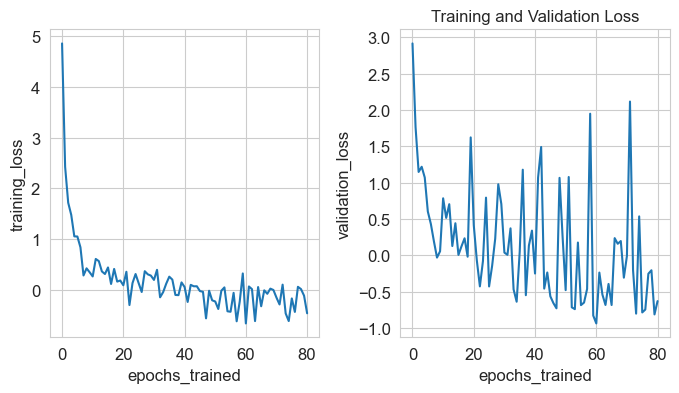

In [44]:
fig, axes = plot_summary(
    inference_summaryNN2, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Plug in observation data to get posterior

In [45]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 2), np.nan)
theta_post.shape

(1965, 1000, 2)

In [46]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior_summaryNN2.sample((num_posterior_samples,),
                                                   x=x_obs_torch[i, :],
                                                   show_progress_bars=False,
                                                   reject_outside_prior=False)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_16932\2003738260.py:5: UserWarning: 76.2% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post_torch = posterior_summaryNN2.sample((num_posterior_samples,),
C:\Users\u2008181\AppData\Local\Temp\ipykernel_16932\2003738260.py:5: UserWarning: 7.1% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post_torch = posterior_summaryNN2.sample((num_posterior_samples,),
C:\Users\u2008181\AppData\Local\Temp\ipykernel_16932\2003738260.py:5: UserWarning: 21.4% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post_torch = posterior_summaryNN2.sample((num_posterior_samples,),
C:\Users\u2008181\AppData\Local\Temp\ipykernel_16932\2003738260.py:5: UserWarning: 29.0% of samples drawn with reject_outside_prior=False lie outside the p

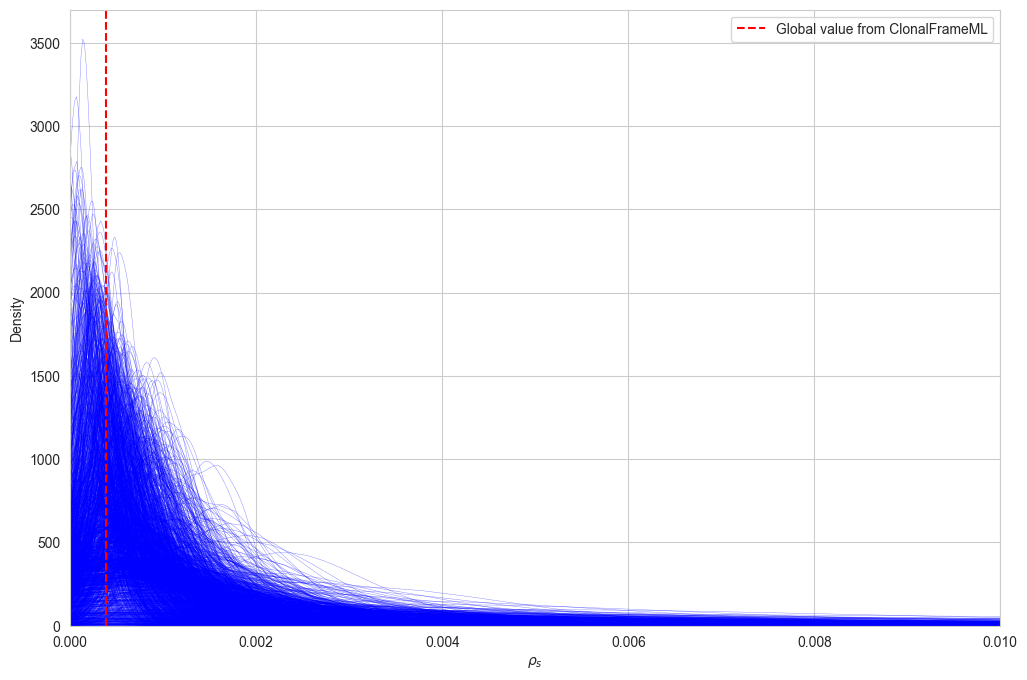

In [47]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    if i in ignore_indices:
        continue
    sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.axvline(x=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.01)
plt.legend()
plt.show()

### Plot bar plots by position

In [48]:
plot_xlim = [0.0, 2902619.0]
samples_x = np.delete(gene_info_np[:, 1], no_signal_id)
samples_x.shape

(1965,)

In [49]:
posterior_median = np.median(theta_post[:, :, 0], axis=1)
posterior_median.shape

(1965,)

In [50]:
ci_lower_bounds = np.percentile(theta_post[:, :, 0], 2.5, axis=1)
ci_upper_bounds = np.percentile(theta_post[:, :, 0], 97.5, axis=1)
ci_lower_bounds.shape, ci_upper_bounds.shape

((1965,), (1965,))

In [51]:
lower_errors = posterior_median - ci_lower_bounds
upper_errors = ci_upper_bounds - posterior_median
yerr = [lower_errors, upper_errors]

In [52]:
median_rho = np.median(posterior_median)
median_rho

np.float64(0.0005162196466699243)

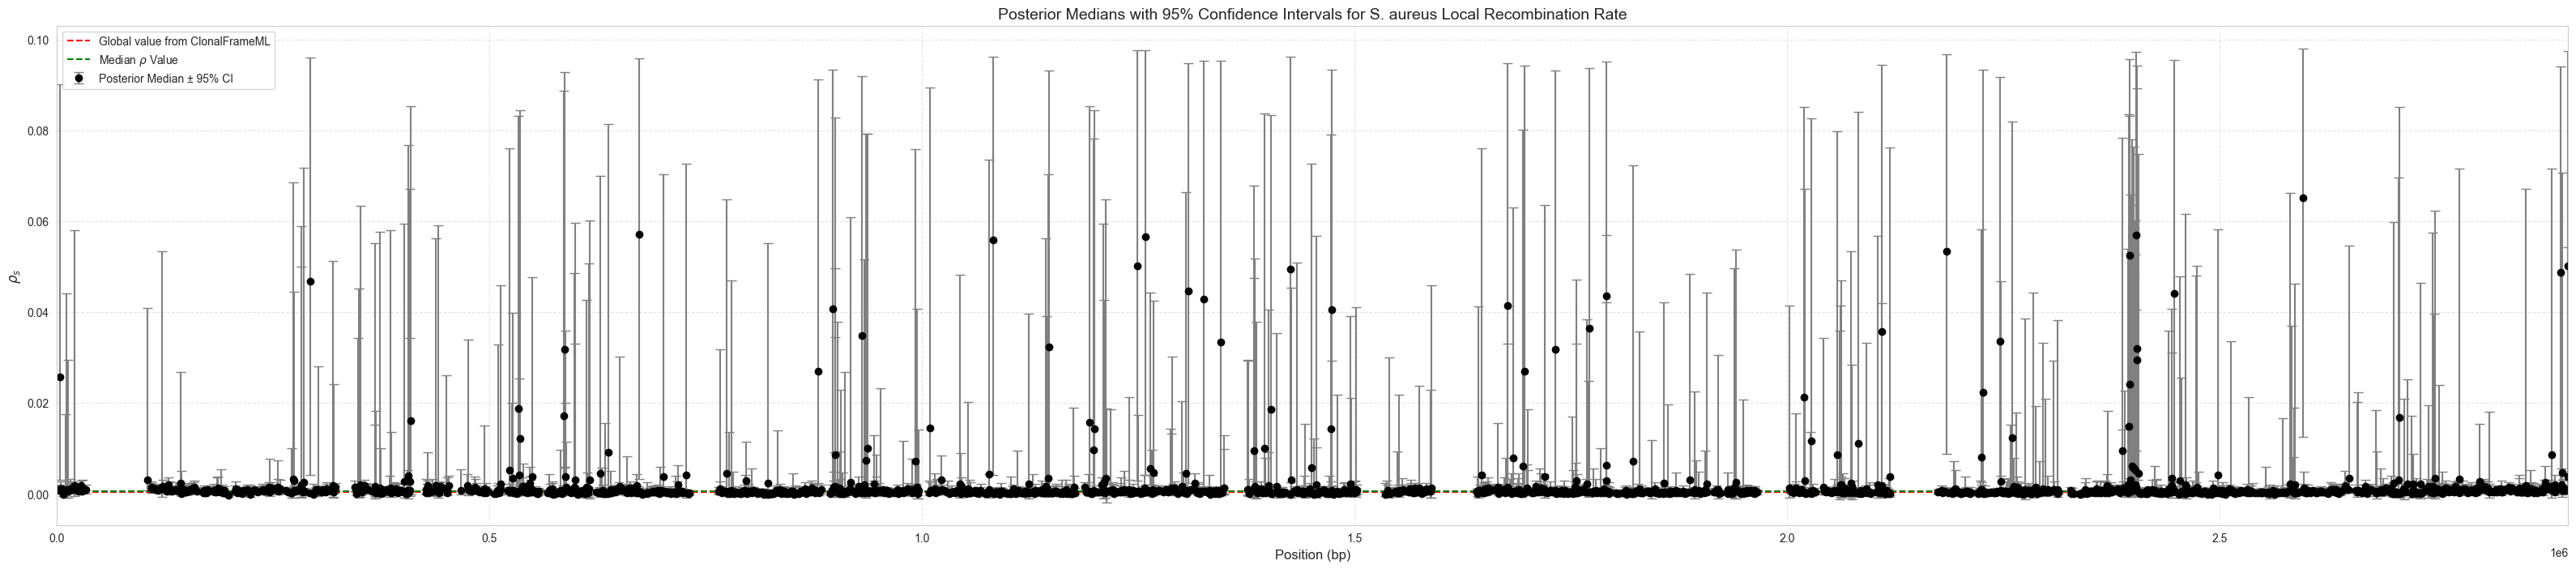

In [53]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median, yerr=yerr, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for S. aureus Local Recombination Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_rho, color='green', linestyle='dashed', label=r'Median $\rho$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [54]:
samples_l = np.delete(gene_info_np[:, 0], no_signal_id)
samples_l.shape

(1965,)

In [55]:
posterior_l_median = np.median(theta_post[:, :, 1], axis=1)
posterior_l_median.shape

(1965,)

In [56]:
ci_lower_bounds_l = np.percentile(theta_post[:, :, 1], 2.5, axis=1)
ci_upper_bounds_l = np.percentile(theta_post[:, :, 1], 97.5, axis=1)
ci_lower_bounds_l.shape, ci_upper_bounds_l.shape

((1965,), (1965,))

In [57]:
lower_l_errors = posterior_l_median - ci_lower_bounds_l
upper_l_errors = ci_upper_bounds_l - posterior_l_median
yerr_l = [lower_l_errors, upper_l_errors]

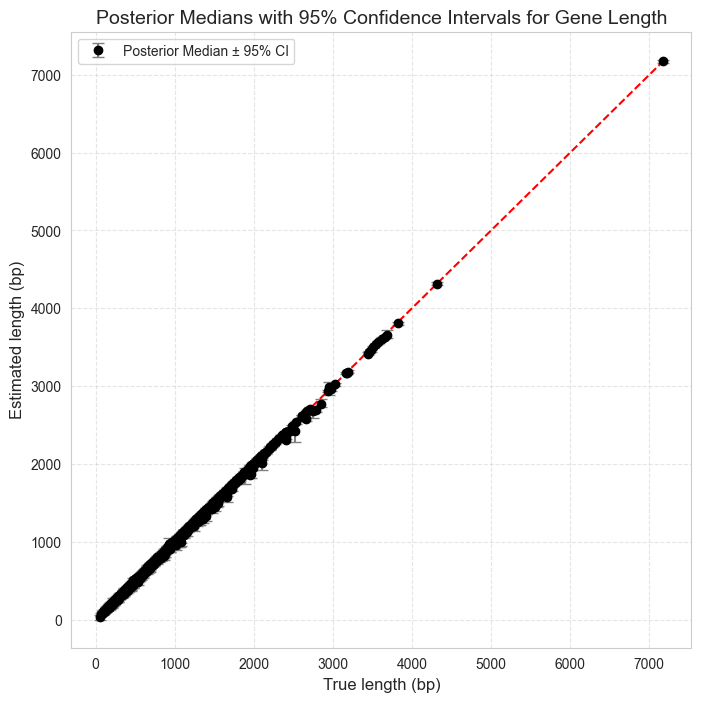

In [58]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l, posterior_l_median, yerr=yerr_l, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l), np.max(samples_l), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for Gene Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

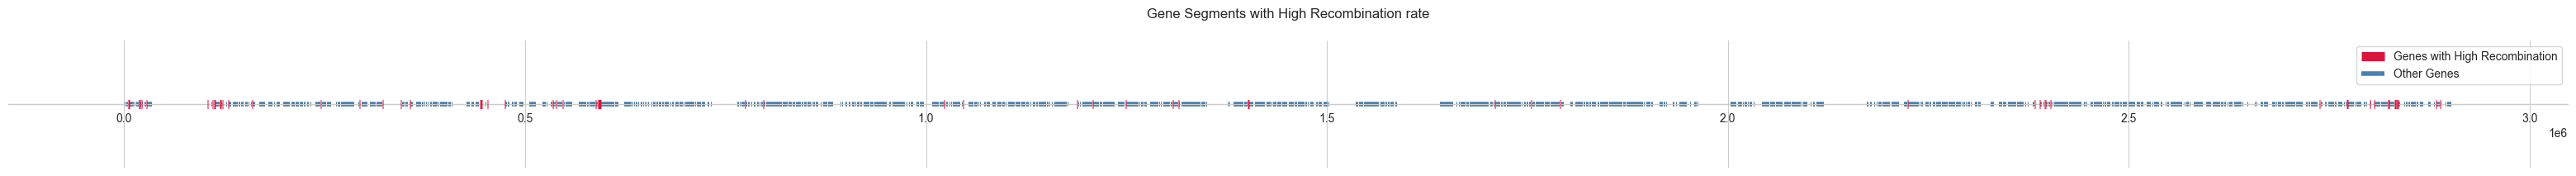

In [59]:
y_level = 0
gene_starts = np.delete(gene_info_np[:, 1], no_signal_id)
gene_ends   = np.delete(gene_info_np[:, 2], no_signal_id)

# high_recomb_index = np.where(ci_lower_bounds >= 0.0003887292720131564)[0]
high_recomb_index = np.where(ci_lower_bounds >= median_rho)[0]
highlight_starts = gene_starts[high_recomb_index]
highlight_ends   = gene_ends[high_recomb_index]

# other_genes_index = np.where(ci_lower_bounds < 0.0003887292720131564)[0]
other_genes_index = np.where(ci_lower_bounds < median_rho)[0]
other_starts = gene_starts[other_genes_index]
other_ends   = gene_ends[other_genes_index]

fig, ax = plt.subplots(figsize=(40, 2))

ax.axhline(y=y_level, color='lightgray', linewidth=1, zorder=1)
ax.hlines(y=[y_level] * len(highlight_starts), xmin=highlight_starts, xmax=highlight_ends, 
          color='crimson', linewidth=8, label='Genes with High Recombination', zorder=3)
ax.hlines(y=[y_level] * len(other_starts), xmin=other_starts, xmax=other_ends, 
          color='steelblue', linewidth=4, label='Other Genes', zorder=2)

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position('center')

ax.set_ylim(-1, 1)
ax.set_title("Gene Segments with High Recombination rate", pad=20)
ax.legend(loc='upper right')
plt.show()